In [1]:
import sys
sys.path.append("..")

import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters, sample_total_distribution
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time, visualize_connectivity_with_non_local_couplings
from physical_diffusion_fns.network_fns import setup_duffing_network_with_external_force_energy_fn, setup_overdamped_SDE, solve_SDE, create_2d_square_lattice_connectivity, setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_energy_fn,setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn

jax.config.update("jax_enable_x64", True)

2025-05-14 00:00:49.812606: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.8.93. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Setup Problem

### Generate samples from a Gaussian mixture - the target distribution

In [2]:
# Set random seed
key_seed = 10    
key = jr.PRNGKey(key_seed)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 1000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [1., 1.],   # mean of first Gaussian
    [-1., -1.],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal of target distributions

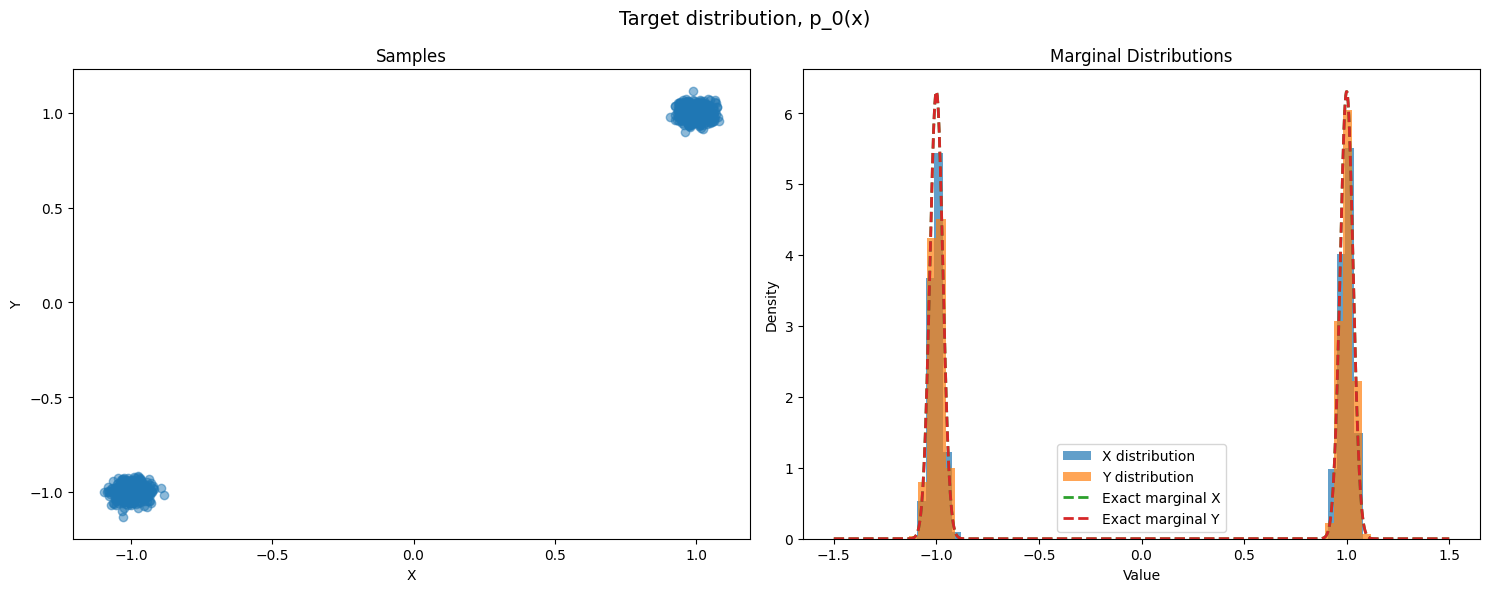

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Physical system

## Network size and topology

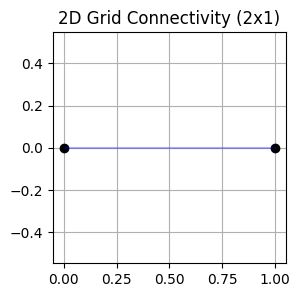

In [4]:
N_osc = 2
connectivity = jnp.array([[0, 1]])
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

## Energy

In [5]:
energy_fn_type = "6th_order_duffing_coupling"
if energy_fn_type == "6th_order_duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    k_6_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, k_6_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'k_6', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_k6_self = jnp.arange(2*N_osc,3*N_osc)
    constraint_indices = constraint_indices_k6_self

    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn(connectivity, unflatten)
elif energy_fn_type == "duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_duff_self = jnp.arange(N_osc,2*N_osc)
    constraint_indices_duff_coupling = jnp.arange(2*N_osc+2*num_connections,2*N_osc+3*num_connections)
    constraint_indices = jnp.concatenate([constraint_indices_duff_self, constraint_indices_duff_coupling])
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_energy_fn(connectivity, unflatten)
elif energy_fn_type == "duffing_optomech_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices = jnp.arange(N_osc,2*N_osc)
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_energy_fn(connectivity, unflatten)
else:
    raise ValueError(f"Unknown energy function type: {energy_fn_type}. Choose from '6th_order_duffing_coupling' or 'duffing_coupling'.")

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


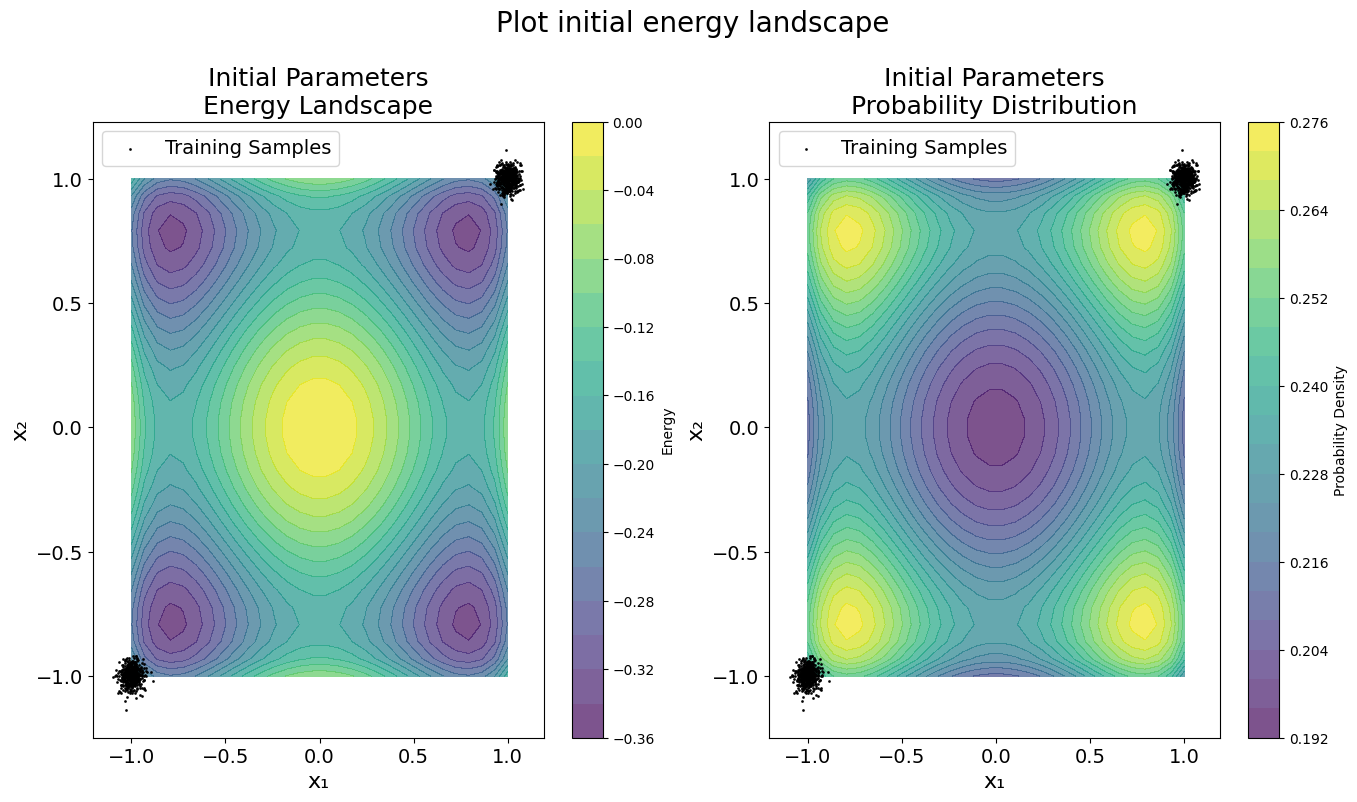

In [6]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [7]:
# Choose training method
training_method = "CD1"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)
Temp = .1
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=Temp, key=jr.PRNGKey(33), num_noise_samples=2000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")


#### Optimization parameters and filenames

In [8]:
# Forward process parameters
n_time_steps = 10
t_forward = 10
sigma_forward = 1.
exponential_time_pts = False
if exponential_time_pts:
    forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-7), jnp.log(t_forward), n_time_steps))
    forward_time_pts = forward_time_pts.at[0].set(0.)
else:
    forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
# print('forward_time_pts', forward_time_pts)

# Optimization parameters
training_method = "SM"
learning_rate = 0.01
n_epochs = 100000
batch_size = 4*128
window_size=100
tolerance=1e-6
patience=50

In [9]:
problem_type_folder = f"gaussian_mixture/Energy_fn_type_{energy_fn_type}"
optimization_folder = (
           f"exp_time_pts_{exponential_time_pts}_"
           f"t_forward_{t_forward}_"
           f"n_timesteps_{n_time_steps}_"
           f"sigma_forward_{sigma_forward}_"
           f"lr_{learning_rate}_"
           f"epochs_{n_epochs}_"
           f"batch_{batch_size}_"
           f"window_{window_size}_"
           f"tol_{tolerance}_"
           f"patience_{patience}")

# Setup output directories
base_dir = "../out/problems"
output_dir = os.path.join(base_dir, problem_type_folder, f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}", optimization_folder)
plot_folder = os.path.join(output_dir, 'aaa_final_plots')

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plot_folder, exist_ok=True)
print(f"Output directory: {output_dir}")
print(f"Plot directory: {plot_folder}")

save_fig = False

Output directory: ../out/problems/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling/weights_[0.5 0.5]_means_[ 1.  1. -1. -1.]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/exp_time_pts_False_t_forward_10_n_timesteps_10_sigma_forward_1.0_lr_0.01_epochs_100000_batch_512_window_100_tol_1e-06_patience_50
Plot directory: ../out/problems/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling/weights_[0.5 0.5]_means_[ 1.  1. -1. -1.]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/exp_time_pts_False_t_forward_10_n_timesteps_10_sigma_forward_1.0_lr_0.01_epochs_100000_batch_512_window_100_tol_1e-06_patience_50/aaa_final_plots


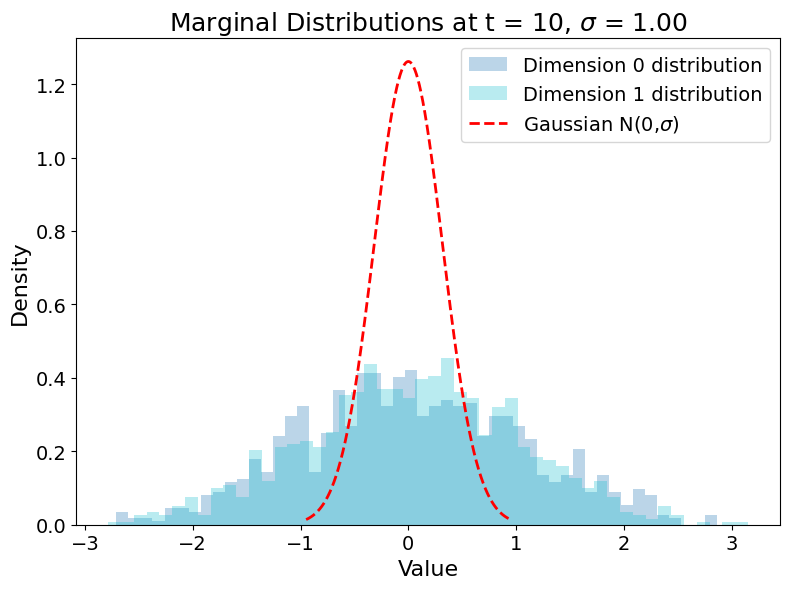

In [10]:
key, subkey = jr.split(key)
samples_t = sample_total_distribution(t_forward, n_samples, D=Temp, sigma_final=1/jnp.sqrt(Temp), samples0=samples_0, key=subkey, k=1, beta= 1)
plot_forward_marginals(samples_t, t_forward, sigma_forward, Temp=Temp, path=plot_folder, save_fig=save_fig, fontsize=16, plot_show=True)

No existing parameters found, running optimization
t_idx: 0, t_curr: 0.0
Epoch 0 - Loss: -13.0333
Epoch 100 - Loss: -17.1580
Epoch 200 - Loss: -26.5716
Epoch 300 - Loss: -36.2257
Epoch 400 - Loss: -45.8424
Epoch 500 - Loss: -54.6802
Epoch 600 - Loss: -63.4080
Epoch 700 - Loss: -72.2991
Epoch 800 - Loss: -79.8560
Epoch 900 - Loss: -87.3168
Epoch 1000 - Loss: -94.3309
Epoch 1100 - Loss: -101.4667
Epoch 1200 - Loss: -107.1675
Epoch 1300 - Loss: -113.2093
Epoch 1400 - Loss: -118.9556
Epoch 1500 - Loss: -124.4516
Epoch 1600 - Loss: -128.7003
Epoch 1700 - Loss: -132.3649
Epoch 1800 - Loss: -136.1150
Epoch 1900 - Loss: -140.6886
Epoch 2000 - Loss: -142.5745
Epoch 2100 - Loss: -145.1195
Epoch 2200 - Loss: -147.9766
Epoch 2300 - Loss: -150.5576
Epoch 2400 - Loss: -153.5340
Epoch 2500 - Loss: -155.4147
Epoch 2600 - Loss: -155.8881
Epoch 2700 - Loss: -158.4365
Epoch 2800 - Loss: -158.4823
Epoch 2900 - Loss: -159.3175
Epoch 3000 - Loss: -159.3918
Epoch 3100 - Loss: -161.4139
Epoch 3200 - Loss: -16

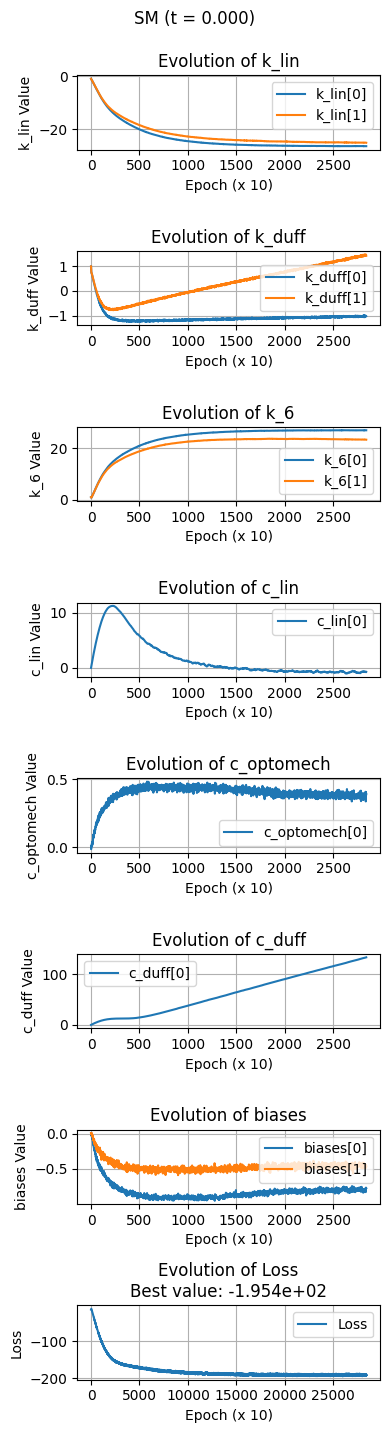

t_idx: 1, t_curr: 1.1111111111111112
Epoch 0 - Loss: 891.9031
Epoch 100 - Loss: 879.0613
Epoch 200 - Loss: 776.9103
Epoch 300 - Loss: 860.0768
Epoch 400 - Loss: 641.7310
Epoch 500 - Loss: 663.6410
Epoch 600 - Loss: 534.0260
Epoch 700 - Loss: 622.0772
Epoch 800 - Loss: 347.8439
Epoch 900 - Loss: 460.0636
Epoch 1000 - Loss: 497.3911
Epoch 1100 - Loss: 257.5057
Epoch 1200 - Loss: 335.9625
Epoch 1300 - Loss: 359.9127
Epoch 1400 - Loss: 380.7164
Epoch 1500 - Loss: 519.8906
Epoch 1600 - Loss: 369.4275
Epoch 1700 - Loss: 319.4461
Epoch 1800 - Loss: 421.2736
Epoch 1900 - Loss: 238.4543
Epoch 2000 - Loss: 208.9828
Epoch 2100 - Loss: 363.3818
Epoch 2200 - Loss: 275.7228
Epoch 2300 - Loss: 246.4539
Epoch 2400 - Loss: 369.8122
Epoch 2500 - Loss: 181.6415
Epoch 2600 - Loss: 341.8316
Epoch 2700 - Loss: 222.1032
Epoch 2800 - Loss: 296.9192
Epoch 2900 - Loss: 303.5697
Epoch 3000 - Loss: 244.9564
Epoch 3100 - Loss: 264.2589
Epoch 3200 - Loss: 148.2679
Epoch 3300 - Loss: 206.6637
Epoch 3400 - Loss: 197.

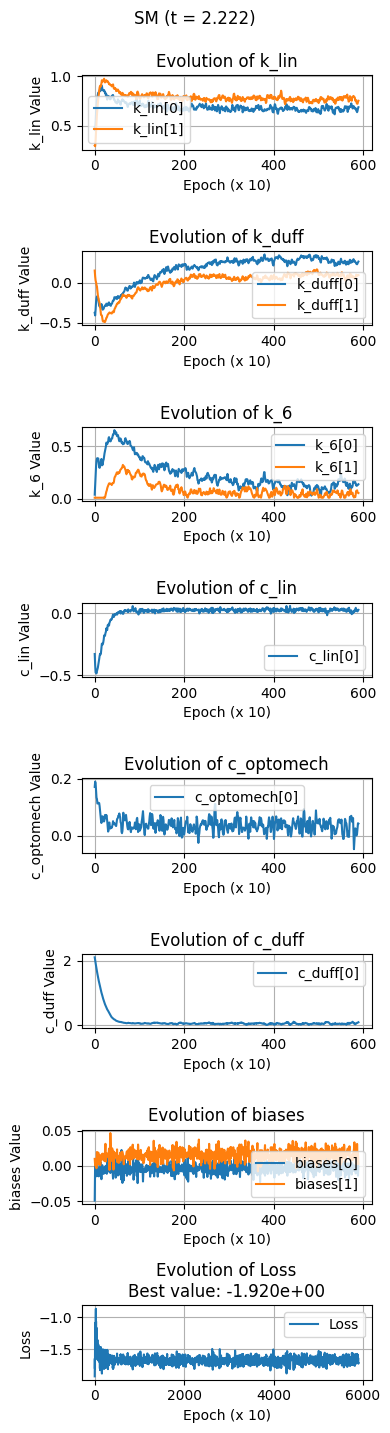

t_idx: 3, t_curr: 3.3333333333333335
Epoch 0 - Loss: -1.6984
Epoch 100 - Loss: -1.8592
Epoch 200 - Loss: -1.9191
Epoch 300 - Loss: -2.0507
Epoch 400 - Loss: -2.0402
Epoch 500 - Loss: -1.9443
Epoch 600 - Loss: -1.9977
Epoch 700 - Loss: -2.0364
Epoch 800 - Loss: -1.9661
Epoch 900 - Loss: -1.9719
Epoch 1000 - Loss: -1.9209
Epoch 1100 - Loss: -1.9926
Epoch 1200 - Loss: -1.9755
Epoch 1300 - Loss: -1.9128
Epoch 1400 - Loss: -1.9268
Epoch 1500 - Loss: -1.9471
Epoch 1600 - Loss: -1.9524
Epoch 1700 - Loss: -1.8753
Epoch 1800 - Loss: -2.0619
Epoch 1900 - Loss: -1.9176
Epoch 2000 - Loss: -1.8793
Epoch 2100 - Loss: -2.0384
Epoch 2200 - Loss: -1.8631
Epoch 2300 - Loss: -1.9173
Epoch 2400 - Loss: -1.9246
Epoch 2500 - Loss: -1.8396
Epoch 2600 - Loss: -1.9879
Epoch 2700 - Loss: -2.0415
Epoch 2800 - Loss: -1.9920
Epoch 2900 - Loss: -2.0784
Epoch 3000 - Loss: -2.0029
Epoch 3100 - Loss: -1.9426
Epoch 3200 - Loss: -2.0814
Epoch 3300 - Loss: -1.9226
Epoch 3400 - Loss: -1.9105
Epoch 3500 - Loss: -1.9607
Epo

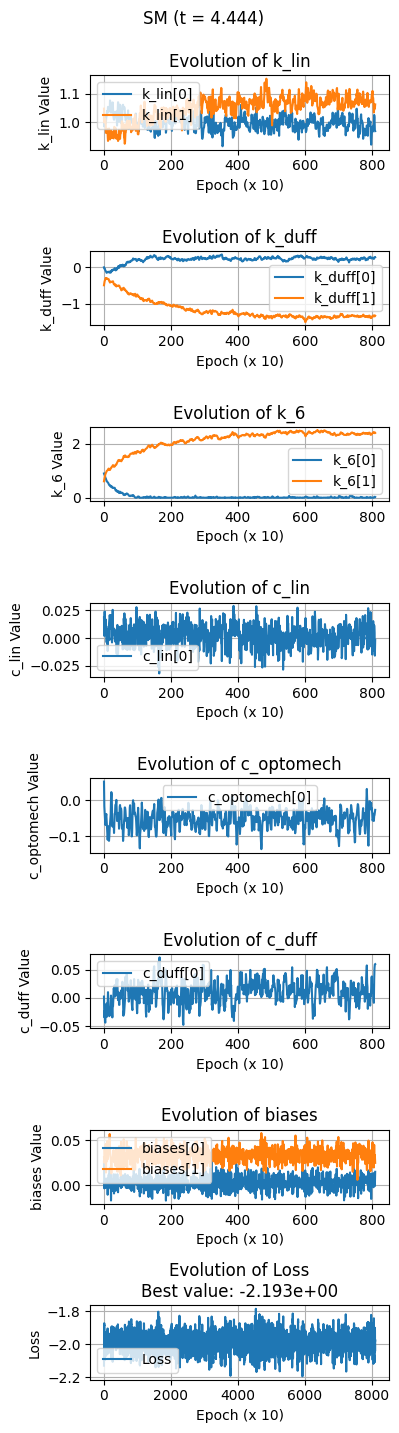

t_idx: 5, t_curr: 5.555555555555555
Epoch 0 - Loss: -2.1574
Epoch 100 - Loss: -1.9017
Epoch 200 - Loss: -2.0006
Epoch 300 - Loss: -1.8452
Epoch 400 - Loss: -1.9137
Epoch 500 - Loss: -1.9234
Epoch 600 - Loss: -1.9202
Epoch 700 - Loss: -1.9458
Epoch 800 - Loss: -1.9388
Epoch 900 - Loss: -1.8874
Epoch 1000 - Loss: -1.9084
Epoch 1100 - Loss: -2.0018
Epoch 1200 - Loss: -1.9497
Epoch 1300 - Loss: -1.9506
Epoch 1400 - Loss: -1.9259
Epoch 1500 - Loss: -1.8958
Epoch 1600 - Loss: -1.9517
Epoch 1700 - Loss: -2.0236
Epoch 1800 - Loss: -1.9996
Epoch 1900 - Loss: -1.9802
Epoch 2000 - Loss: -1.8575
Epoch 2100 - Loss: -1.8868
Epoch 2200 - Loss: -2.0193
Epoch 2300 - Loss: -1.9150
Epoch 2400 - Loss: -1.9336
Epoch 2500 - Loss: -1.9472
Epoch 2600 - Loss: -1.9909
Epoch 2700 - Loss: -2.0009
Epoch 2800 - Loss: -1.9225
Epoch 2900 - Loss: -1.9165
Epoch 3000 - Loss: -1.8787
Epoch 3100 - Loss: -2.0185
Epoch 3200 - Loss: -2.0391
Epoch 3300 - Loss: -1.9901
Epoch 3400 - Loss: -1.9800
Epoch 3500 - Loss: -1.8936
Epoc

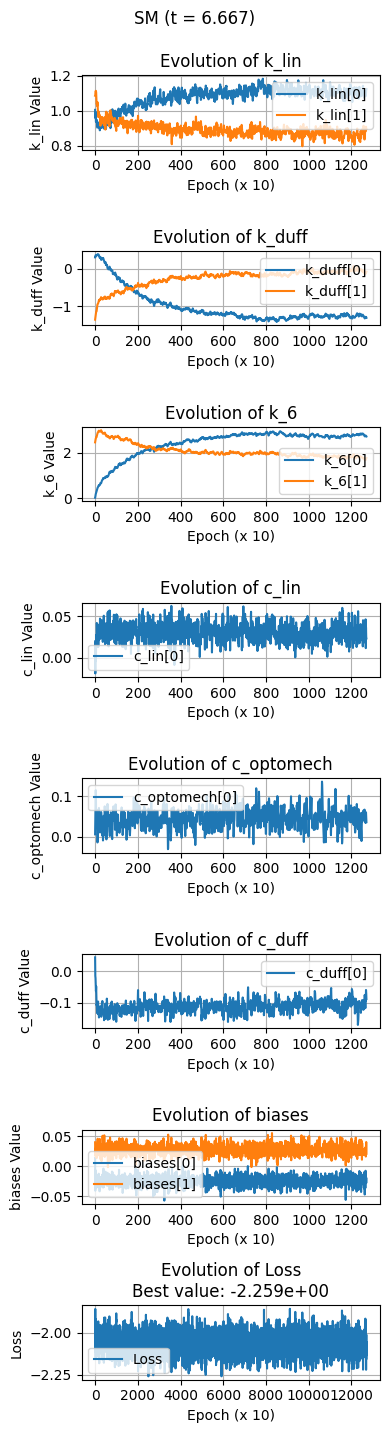

t_idx: 7, t_curr: 7.777777777777779
Epoch 0 - Loss: -2.2608
Epoch 100 - Loss: -1.9759
Epoch 200 - Loss: -2.0076
Epoch 300 - Loss: -1.9929
Epoch 400 - Loss: -2.0433
Epoch 500 - Loss: -1.9702
Epoch 600 - Loss: -2.0524
Epoch 700 - Loss: -2.0073
Epoch 800 - Loss: -1.9444
Epoch 900 - Loss: -2.0452
Epoch 1000 - Loss: -2.0084
Epoch 1100 - Loss: -1.9600
Epoch 1200 - Loss: -1.9374
Epoch 1300 - Loss: -1.9976
Epoch 1400 - Loss: -1.9625
Epoch 1500 - Loss: -1.9376
Epoch 1600 - Loss: -1.9777
Epoch 1700 - Loss: -1.9751
Epoch 1800 - Loss: -1.9380
Epoch 1900 - Loss: -1.9960
Epoch 2000 - Loss: -1.8982
Epoch 2100 - Loss: -1.9427
Epoch 2200 - Loss: -1.9722
Epoch 2300 - Loss: -2.0125
Epoch 2400 - Loss: -1.9365
Epoch 2500 - Loss: -2.0476
Epoch 2600 - Loss: -1.9827
Epoch 2700 - Loss: -1.9494
Epoch 2800 - Loss: -1.9621
Epoch 2900 - Loss: -1.9443
Epoch 3000 - Loss: -1.9477
Epoch 3100 - Loss: -1.9152
Epoch 3200 - Loss: -1.9460
Epoch 3300 - Loss: -2.0052
Epoch 3400 - Loss: -1.9407
Epoch 3500 - Loss: -2.1115
Epoc

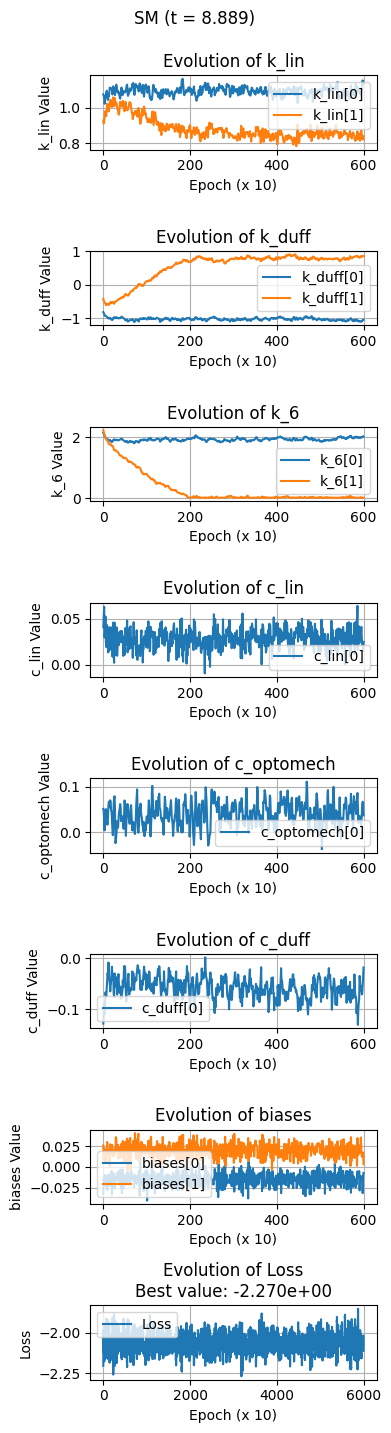

t_idx: 9, t_curr: 10.0
Epoch 0 - Loss: -2.2739
Epoch 100 - Loss: -1.8923
Epoch 200 - Loss: -1.9902
Epoch 300 - Loss: -1.9779
Epoch 400 - Loss: -1.9145
Epoch 500 - Loss: -1.9724
Epoch 600 - Loss: -2.0190
Epoch 700 - Loss: -1.8886
Epoch 800 - Loss: -1.9110
Epoch 900 - Loss: -1.9898
Epoch 1000 - Loss: -1.9583
Epoch 1100 - Loss: -1.9876
Epoch 1200 - Loss: -1.8893
Epoch 1300 - Loss: -1.9644
Epoch 1400 - Loss: -1.9736
Epoch 1500 - Loss: -2.0025
Epoch 1600 - Loss: -1.9496
Epoch 1700 - Loss: -1.9780
Epoch 1800 - Loss: -1.9382
Epoch 1900 - Loss: -1.8782
Epoch 2000 - Loss: -1.8876
Epoch 2100 - Loss: -1.8423
Epoch 2200 - Loss: -1.8886
Epoch 2300 - Loss: -1.9941
Epoch 2400 - Loss: -1.8871
Epoch 2500 - Loss: -1.9822
Epoch 2600 - Loss: -1.9686
Epoch 2700 - Loss: -1.9200
Epoch 2800 - Loss: -1.8660
Epoch 2900 - Loss: -1.9877
Epoch 3000 - Loss: -1.9423
Epoch 3100 - Loss: -1.8892
Epoch 3200 - Loss: -1.9877
Epoch 3300 - Loss: -1.9222
Epoch 3400 - Loss: -1.9722
Epoch 3500 - Loss: -1.9713
Epoch 3600 - Loss

In [11]:
params_history_path = f"{output_dir}/params_history.npy"
if os.path.exists(params_history_path):
    # Load existing parameters
    print('Loading existing parameters from', params_history_path)
    params_history_all_t = jnp.load(params_history_path)
else:
    print('No existing parameters found, running optimization')
    key, subkey = jr.split(key)
    
    samples_t = sample_total_distribution(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey, k=1.)
    plot_forward_marginals(samples_t, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=save_fig, fontsize=16)
    
    # Setup optimization parameters
    mask = jnp.ones(params_flattened_initial.shape[0])

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 2     # Plot every nth step

    params_history_all_t = []
    current_params = params_flattened_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"t_idx: {t_idx}, t_curr: {t_curr}")
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_curr, n_samples, D=Temp, sigma_final=sigma_forward, samples0=samples_0, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate, 
            n_epochs=n_epochs, 
            maximize=maximize, 
            window_size=window_size, 
            tolerance=tolerance, 
            patience=patience, 
            constraint_indices=constraint_indices
        )
        
        _, current_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=save_fig,
                    path=output_dir,
                    param_names=params_names,
                    plot_show=True
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    # jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)

    print('Optimization complete; saved parameters to', output_dir)

### Smoothen and interpolate parameter evolution

In [12]:
use_smoothed_params = False
smoothed_params = smooth_parameters(params_history_all_t, window_lengths=[10] * params_history_all_t.shape[1], poly_orders=[3] * params_history_all_t.shape[1])

# Get interpolator functions
params_interpolator_smoothed = interpolate_parameters(smoothed_params, forward_time_pts)
params_interpolator_non_smoothed = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0], forward_time_pts[-1], 200)
interpolated_params_smoothed = params_interpolator_smoothed(time_eval)
interpolated_params_non_smoothed = params_interpolator_non_smoothed(time_eval)

plot_parameter_as_fn_of_time(params_names, forward_time_pts, forward_time_pts, params_history_all_t, params_interpolator_smoothed, unflatten, N_osc, save_fig=True, path=plot_folder, log_scale=False)

if use_smoothed_params:
    params_interpolator = params_interpolator_smoothed
else:
    params_interpolator = params_interpolator_non_smoothed

### Run reverse SDE:

In [ ]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:N_osc].set(1.)

params_interpolator_reverse_plus_linear = lambda t: params_interpolator(t_forward - t) 

# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True, Temp=Temp)

t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.00000001
atol = 1e-3
rtol = 1e-5

n_trajectories = 1000

# Generate multiple initial states
key, subkey = jr.split(key)
initial_states = sample_forward_process(t_forward, n_trajectories, sigma_final=sigma_forward, D=Temp, samples0=samples_0, key=subkey)

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn,
        diffusion_fn,
        init_state,
        key_b,
        t0,
        t1,
        ts.shape[0],
        dt0,
        rtol=rtol,
        atol=atol
    ),
    in_axes=(0, 0)
)

# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys
final_states = all_trajectories[:, -1, :]

/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

### Run equillibirum SDE

In [14]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 0.2
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.0,0.])
key, subkey = jr.split(key)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,subkey, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

## Plot samples

Solution from reverse process probability distribution total (should be ≈ 1): 1.000000


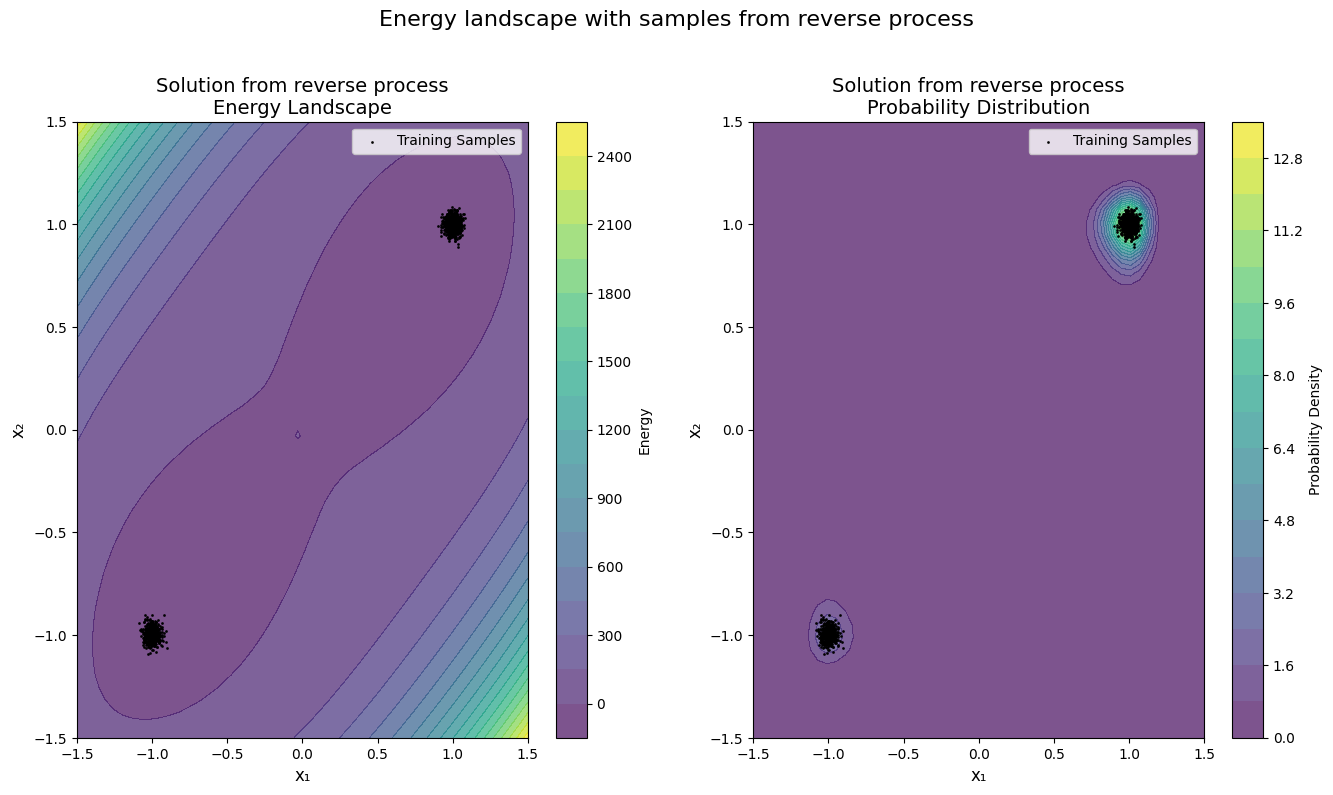

In [15]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

Solution from direct integration probability distribution total (should be ≈ 1): 1.000000


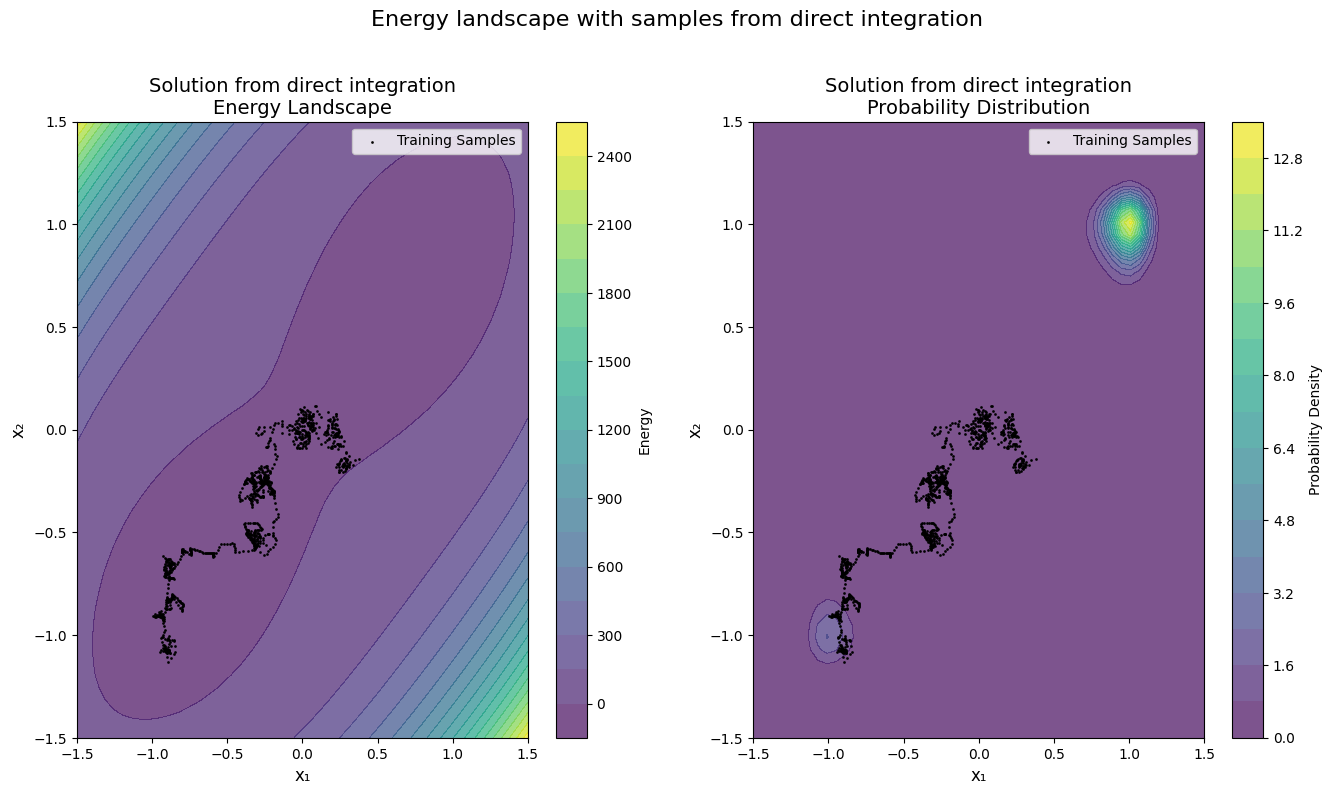

In [16]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

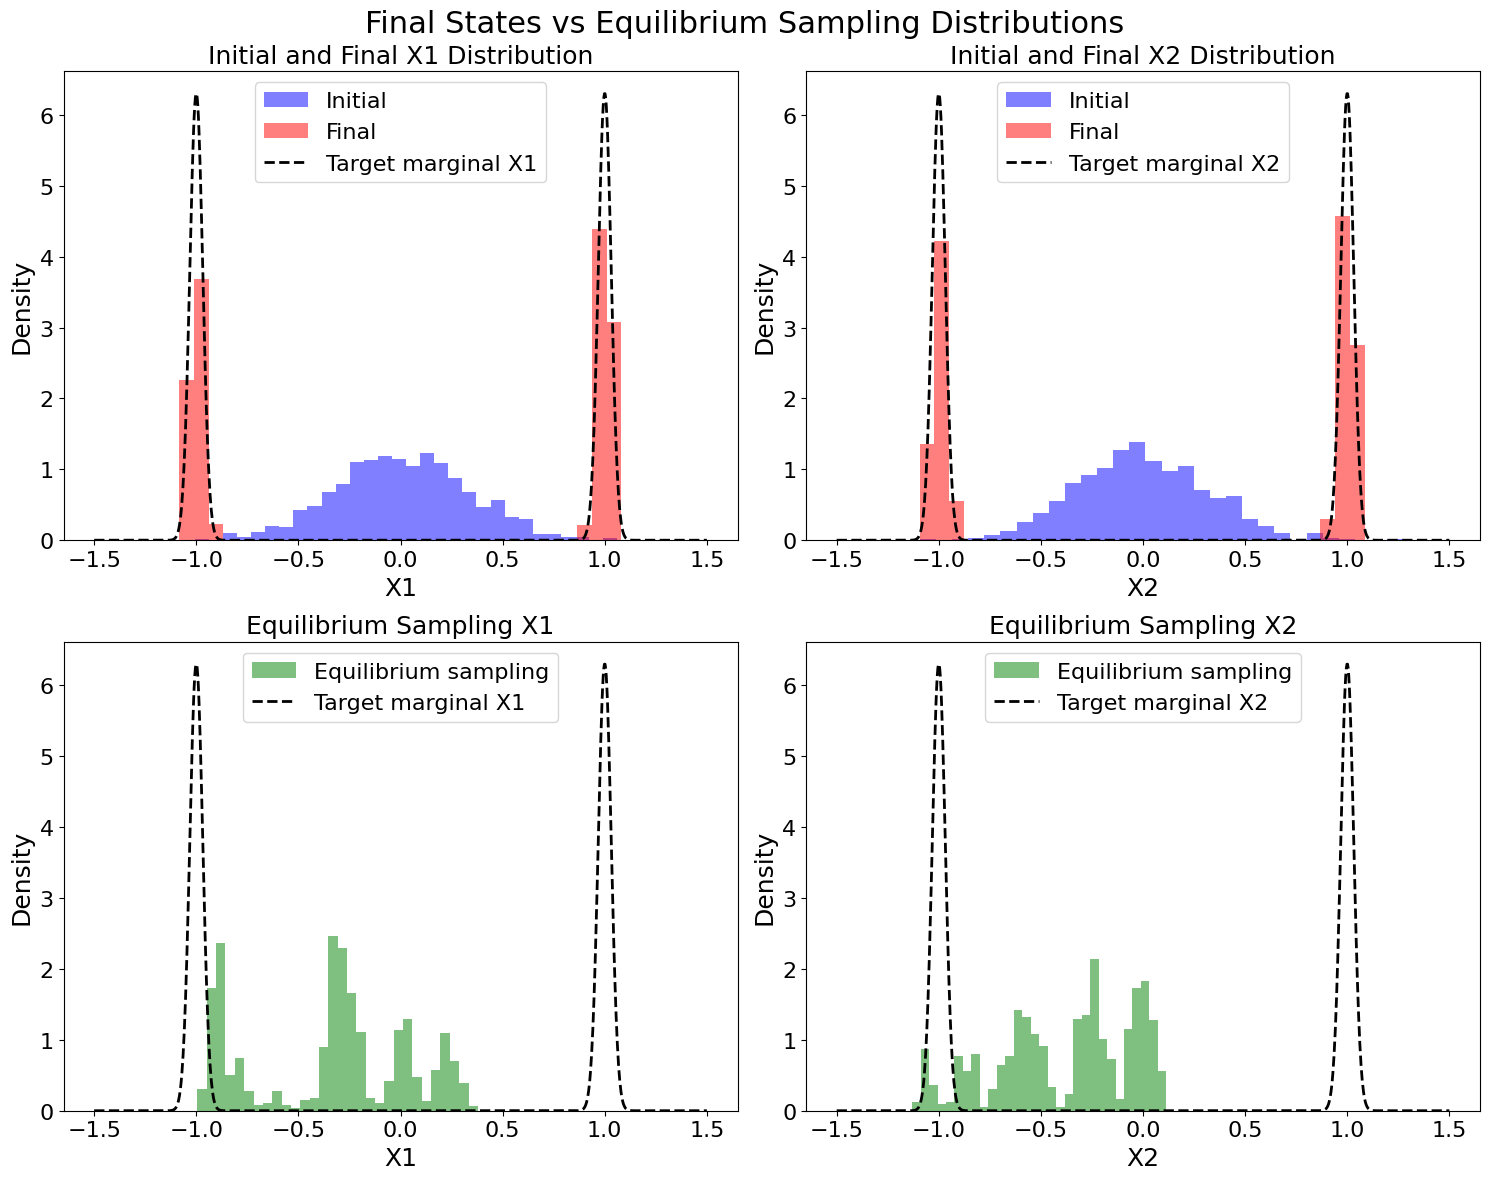

In [17]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()

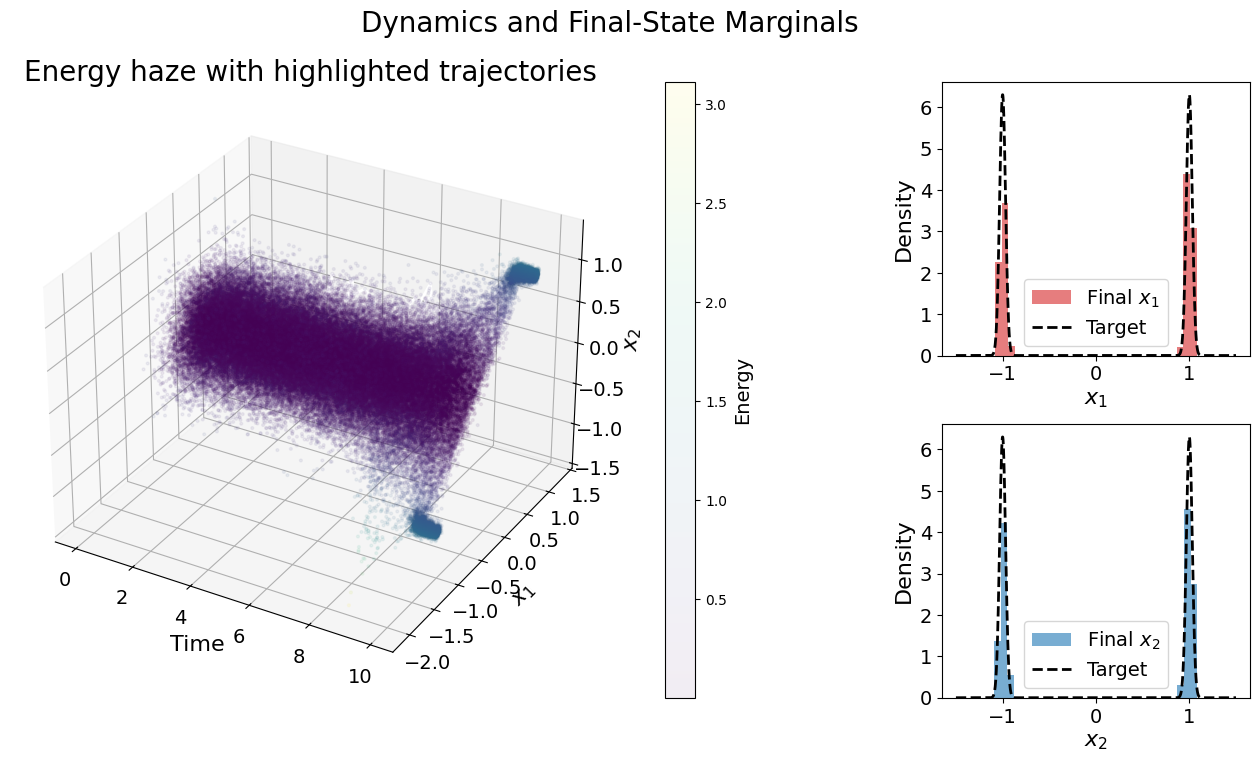

In [29]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D    # noqa: F401
from matplotlib import gridspec, cm

# ----------------------------------------------------------------------
# 1.  RAW DATA ---------------------------------------------------------
# ----------------------------------------------------------------------
ys = solutions.ys.astype(np.float32)              # (N_traj, T, 2)
ts_raw = np.asarray(solutions.ts, dtype=np.float32)

# Gaussian‑mixture params (cast to float32)
weights = weights.astype(np.float32)
means   = means.astype(np.float32)
covs    = covs.astype(np.float32)

def energy(x):                                   # simple placeholder
    return 0.5 * np.sum(x**2, axis=-1, dtype=np.float32)

# ----------------------------------------------------------------------
# 2.  CANONICAL SHAPES -------------------------------------------------
# ----------------------------------------------------------------------
N_traj, T, _ = ys.shape
total_pts = N_traj * T

# ---- convert ts_raw → 1‑D timeline of length T ----------------------
if ts_raw.ndim == 1:
    ts = ts_raw
elif ts_raw.shape[0] == T:       # shape (T, N_traj)  or  (T, …)
    ts = ts_raw[:, 0]
elif ts_raw.shape[1] == T:       # shape (N_traj, T)  or  (…, T)
    ts = ts_raw[0, :]
else:
    # fallback: evenly spaced
    ts = np.linspace(ts_raw.min(), ts_raw.max(), T, dtype=np.float32)

# ensure exact length T
if ts.size != T:
    ts = np.linspace(ts[0], ts[-1], T, dtype=np.float32)

# ----------------------------------------------------------------------
# 3.  SAMPLING FIRST, THEN GATHERING -----------------------------------
# ----------------------------------------------------------------------
max_pts = 100_000                      # points to actually plot
rng = np.random.default_rng(0)
keep = rng.choice(total_pts, size=min(max_pts, total_pts), replace=False)
keep.sort()                            # nicer stripes

traj_idx = keep // T                   # (n_keep,)
time_idx = keep %  T

x1 = ys[traj_idx, time_idx, 0]
x2 = ys[traj_idx, time_idx, 1]
t_flat = ts[time_idx]
xy_flat = np.column_stack([x1, x2])
e_flat = np.asarray(energy(xy_flat), dtype=np.float32)

assert t_flat.size == xy_flat.shape[0] == e_flat.size, "length mismatch!"

# final‑state samples for histograms
final_states = ys[:, -1, :]

# ----------------------------------------------------------------------
# 4.  FIGURE  (energy haze  +  bright trajectories) --------------------
# ----------------------------------------------------------------------
SMALL, MEDIUM, BIG = 14, 16, 20
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[2.5, 1.0],
                       height_ratios=[1, 1], wspace=0.3, hspace=0.25)

ax3d  = fig.add_subplot(gs[:, 0], projection='3d')
ax_x1 = fig.add_subplot(gs[0, 1])
ax_x2 = fig.add_subplot(gs[1, 1], sharex=ax_x1)

# 4‑A  energy cloud (very transparent)
sc = ax3d.scatter(t_flat, xy_flat[:, 0], xy_flat[:, 1],
                  c=e_flat, cmap=cm.viridis,
                  alpha=0.07, s=4, zorder=1)
# keep colour bar if you like
fig.colorbar(sc, ax=ax3d, pad=0.07).set_label('Energy', fontsize=SMALL)

# 4‑B  vivid trajectories on top
traj_color = 'white'          # choose 'red' if you prefer
for idx in np.random.default_rng(1).choice(N_traj, size=min(8, N_traj), replace=False):
    ax3d.plot(ts, ys[idx, :, 0], ys[idx, :, 1],
              color=traj_color, lw=2.0, zorder=2)

ax3d.set_xlabel('Time',   fontsize=MEDIUM)
ax3d.set_ylabel('$x_1$',  fontsize=MEDIUM)
ax3d.set_zlabel('$x_2$',  fontsize=MEDIUM)
ax3d.set_title('Energy haze with highlighted trajectories', fontsize=BIG)
ax3d.tick_params(labelsize=SMALL)

# 4‑C  final‑state histograms (unchanged)
bins = 30
ax_x1.hist(final_states[:, 0], bins=bins, density=True,
           color='tab:red',  alpha=0.6, label='Final $x_1$')
ax_x2.hist(final_states[:, 1], bins=bins, density=True,
           color='tab:blue', alpha=0.6, label='Final $x_2$')

grid = np.linspace(-1.5, 1.5, 1000, dtype=np.float32)
for ax, dim in ((ax_x1, 0), (ax_x2, 1)):
    pdf = sum(w * np.exp(-0.5*((grid - m[dim]) / np.sqrt(c[dim, dim]))**2)
              / (np.sqrt(c[dim, dim]) * np.sqrt(2*np.pi))
              for w, m, c in zip(weights, means, covs))
    ax.plot(grid, pdf, '--k', lw=2, label='Target')
    ax.set_ylabel('Density', fontsize=MEDIUM)
    ax.legend(fontsize=SMALL)
    ax.tick_params(labelsize=SMALL)

ax_x1.set_xlabel('$x_1$', fontsize=MEDIUM)
ax_x2.set_xlabel('$x_2$', fontsize=MEDIUM)

fig.suptitle('Dynamics and Final‑State Marginals', fontsize=BIG, y=0.97)
plt.show()


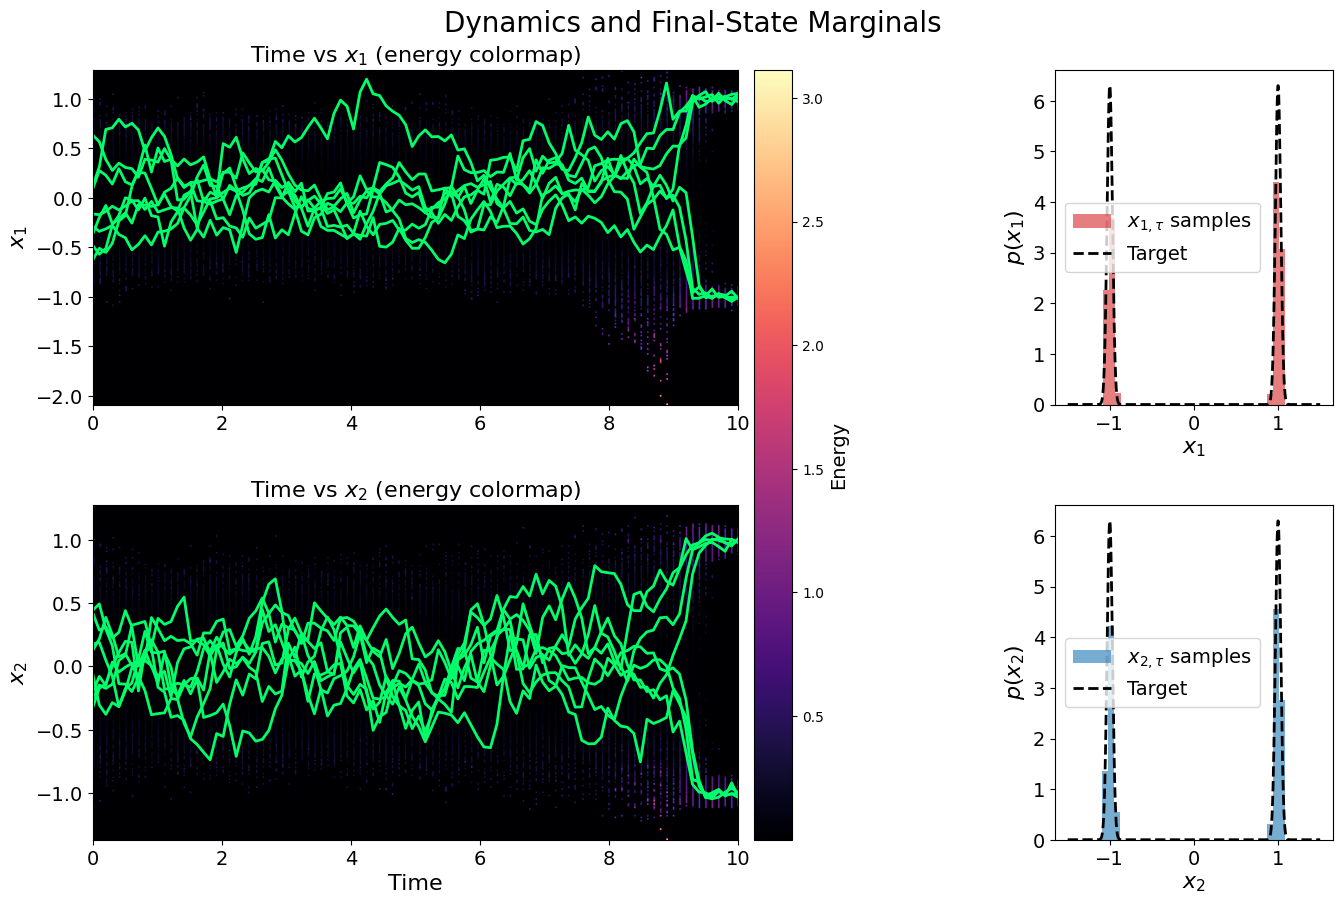

In [32]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import gridspec, cm

# ----------------------------------------------------------------------
# 1.  RAW DATA ---------------------------------------------------------
# ----------------------------------------------------------------------
ys = solutions.ys.astype(np.float32)               # (N_traj, T, 2)
ts_raw = np.asarray(solutions.ts, dtype=np.float32)

# GM parameters → float32
weights = weights.astype(np.float32)
means   = means.astype(np.float32)
covs    = covs.astype(np.float32)

def energy(x):                                     # placeholder Hamiltonian
    return 0.5 * np.sum(x**2, axis=-1, dtype=np.float32)

# ----------------------------------------------------------------------
# 2.  CANONICAL SHAPES -------------------------------------------------
# ----------------------------------------------------------------------
N_traj, T, _ = ys.shape
total_pts = N_traj * T

# convert ts_raw → 1‑D timeline length T
if ts_raw.ndim == 1:
    ts = ts_raw
elif ts_raw.shape[0] == T:      # (T, N_traj) or (T, ...)
    ts = ts_raw[:, 0]
else:                           # (N_traj, T) or (_, T)
    ts = ts_raw[0, :]
if ts.size != T:                # final guard
    ts = np.linspace(ts[0], ts[-1], T, dtype=np.float32)

# ----------------------------------------------------------------------
# 3.  SAMPLE FIRST, THEN GATHER ----------------------------------------
# ----------------------------------------------------------------------
max_pts = 100_000
rng = np.random.default_rng(0)
keep = rng.choice(total_pts, size=min(max_pts, total_pts), replace=False)
keep.sort()

traj_idx = keep // T
time_idx = keep %  T

x1_keep = ys[traj_idx, time_idx, 0]
x2_keep = ys[traj_idx, time_idx, 1]
t_keep  = ts[time_idx]
e_keep  = np.asarray(energy(np.column_stack([x1_keep, x2_keep])), dtype=np.float32)

assert t_keep.size == x1_keep.size == x2_keep.size == e_keep.size

final_states = ys[:, -1, :]          # for marginals

# ----------------------------------------------------------------------
# 4.  FIGURE – energy fog + neon trajectories --------------------------
# ----------------------------------------------------------------------
SMALL, MEDIUM, BIG = 14, 16, 20
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, width_ratios=[2.8, 1.0],
                        height_ratios=[1, 1], wspace=0.35, hspace=0.3)

ax_x1t = fig.add_subplot(gs[0, 0])
ax_x2t = fig.add_subplot(gs[1, 0])
ax_hist1 = fig.add_subplot(gs[0, 1])
ax_hist2 = fig.add_subplot(gs[1, 1], sharex=ax_hist1)

# util: paint an energy fog on a given axis
def plot_energy_fog(ax, t, x, e, *, gridsize=(400, 200), cmap=cm.magma):
    # 2‑D weighted histogram: average energy in each pixel
    bins_t  = np.linspace(t.min(), t.max(), gridsize[0]+1)
    bins_x  = np.linspace(x.min(), x.max(), gridsize[1]+1)

    # sum of energies per bin
    E_sum, _, _ = np.histogram2d(t, x, bins=[bins_t, bins_x], weights=e)
    # counts per bin
    N_cnt, _, _ = np.histogram2d(t, x, bins=[bins_t, bins_x])

    with np.errstate(divide='ignore', invalid='ignore'):
        E_avg = np.nan_to_num(E_sum / N_cnt)      # zeros where N_cnt==0

    # imshow expects (ny, nx); transpose so x‑axis = horizontal = time
    ax.imshow(E_avg.T,
              extent=[t.min(), t.max(), x.min(), x.max()],
              origin='lower',
              aspect='auto',
              cmap=cmap,
              alpha=1.0,
              zorder=0)

# --- paint energy fogs -------------------------------------------------
plot_energy_fog(ax_x1t, t_keep, x1_keep, e_keep, cmap=cm.magma)
plot_energy_fog(ax_x2t, t_keep, x2_keep, e_keep, cmap=cm.magma)

# custom colour bar (share both)
mappable = cm.ScalarMappable(cmap=cm.magma)
mappable.set_array(e_keep)
cbar = fig.colorbar(mappable, ax=[ax_x1t, ax_x2t], pad=0.02)
cbar.set_label('Energy', fontsize=SMALL)

# --- neon trajectories on top -----------------------------------------
for idx in np.random.default_rng(1).choice(N_traj, size=min(8, N_traj), replace=False):
    ax_x1t.plot(ts, ys[idx, :, 0],
                color='#00FF6A', lw=2.0, zorder=2)   # electric‑green
    ax_x2t.plot(ts, ys[idx, :, 1],
                color='#00FF6A', lw=2.0, zorder=2)

# --- axis styling ------------------------------------------------------
ax_x1t.set_ylabel('$x_1$', fontsize=MEDIUM)
ax_x1t.set_title('Time vs $x_1$ (energy colormap)', fontsize=MEDIUM)
ax_x2t.set_ylabel('$x_2$', fontsize=MEDIUM)
ax_x2t.set_xlabel('Time', fontsize=MEDIUM)
ax_x2t.set_title('Time vs $x_2$ (energy colormap)', fontsize=MEDIUM)
for ax in (ax_x1t, ax_x2t):
    ax.tick_params(labelsize=SMALL)

# ----------------------------------------------------------------------
# 4‑B  FINAL‑STATE MARGINALS  (same as before, but new labels) ---------
# ----------------------------------------------------------------------
bins = 30
ax_hist1.hist(final_states[:, 0], bins=bins, density=True,
              color='tab:red', alpha=0.6, label=r'$x_{1,\tau}$ samples')
ax_hist2.hist(final_states[:, 1], bins=bins, density=True,
              color='tab:blue', alpha=0.6, label=r'$x_{2,\tau}$ samples')

grid = np.linspace(-1.5, 1.5, 1000, dtype=np.float32)
for ax, dim in ((ax_hist1, 0), (ax_hist2, 1)):
    pdf = sum(w * np.exp(-0.5*((grid - m[dim]) / np.sqrt(c[dim, dim]))**2)
              / (np.sqrt(c[dim, dim]) * np.sqrt(2*np.pi))
              for w, m, c in zip(weights, means, covs))
    ax.plot(grid, pdf, '--k', lw=2, label='Target')
    ax.set_ylabel(r'$p(x_{%d})$' % (dim+1), fontsize=MEDIUM)
    ax.legend(fontsize=SMALL)
    ax.tick_params(labelsize=SMALL)

ax_hist1.set_xlabel('$x_1$', fontsize=MEDIUM)
ax_hist2.set_xlabel('$x_2$', fontsize=MEDIUM)

fig.suptitle('Dynamics and Final‑State Marginals', fontsize=BIG, y=0.94)
plt.show()


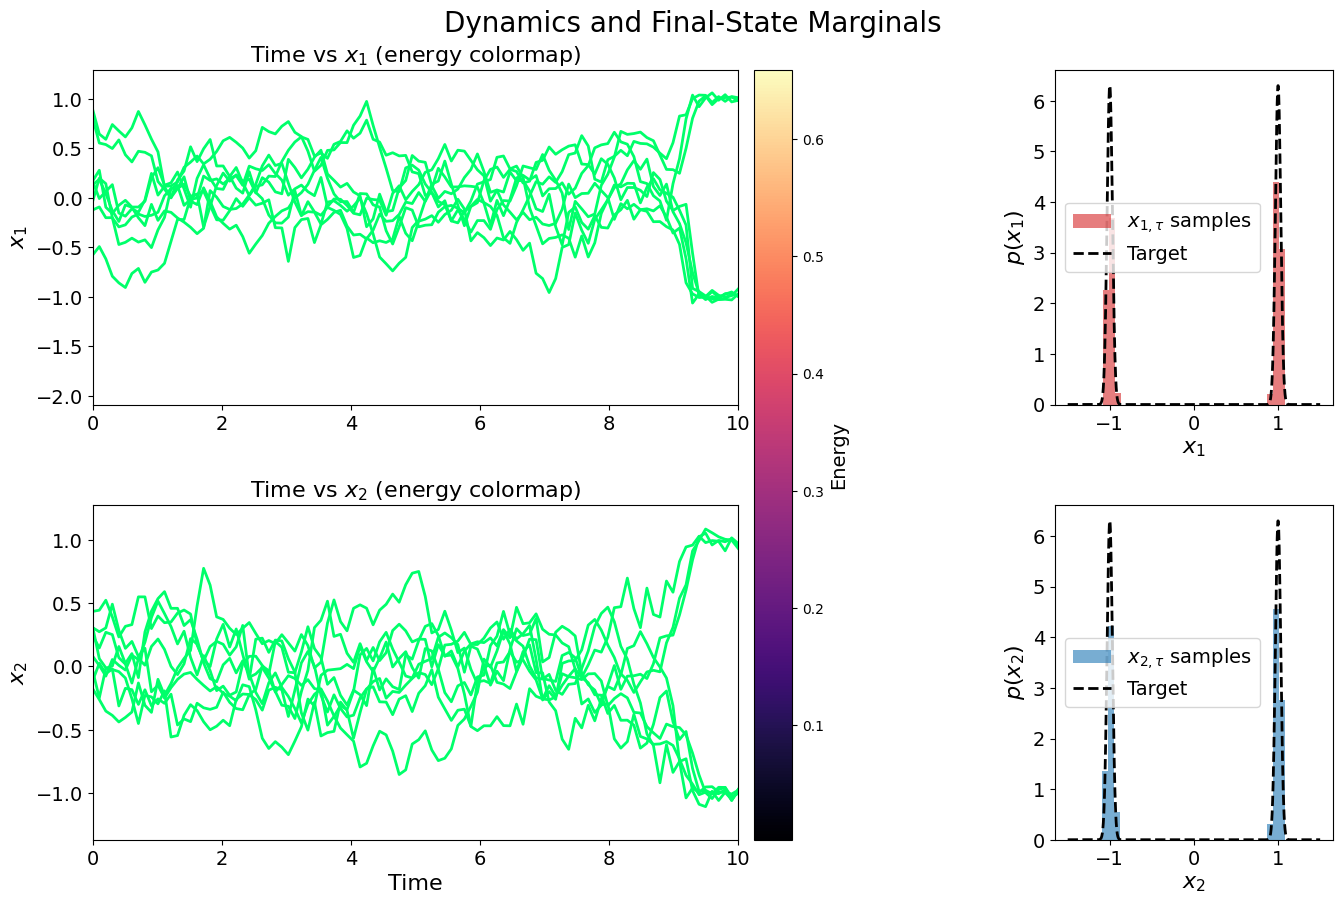

In [33]:
# ===============================================================
#  COMPLETE SCRIPT:   energy colormap + neon trajectories
# ===============================================================
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import gridspec, cm
from scipy.ndimage import gaussian_filter      # for smooth colormap

# ------------------------------------------------------------------
# 1.  RAW DATA (assumed already in memory) --------------------------
# ------------------------------------------------------------------
ys      = solutions.ys.astype(np.float32)            # (N_traj, T, 2)
ts_raw  = np.asarray(solutions.ts, dtype=np.float32) # can be 1‑D or 2‑D

weights = weights.astype(np.float32)
means   = means.astype(np.float32)
covs    = covs.astype(np.float32)

def energy(x):                                      # placeholder Hamiltonian
    return 0.5 * np.sum(x**2, axis=-1, dtype=np.float32)

# ------------------------------------------------------------------
# 2.  CANONICAL SHAPES ---------------------------------------------
# ------------------------------------------------------------------
N_traj, T, _ = ys.shape

# -- timeline ts : 1‑D of length T
if ts_raw.ndim == 1:
    ts = ts_raw
elif ts_raw.shape[0] == T:   # shape (T, N_traj) or (T, …)
    ts = ts_raw[:, 0]
else:                        # shape (N_traj, T) or (…, T)
    ts = ts_raw[0, :]
if ts.size != T:
    ts = np.linspace(ts[0], ts[-1], T, dtype=np.float32)

# ------------------------------------------------------------------
# 3.  SUB‑SAMPLE BEFORE GATHERING ----------------------------------
# ------------------------------------------------------------------
max_pts = 100_000
rng = np.random.default_rng(0)

total_pts = N_traj * T
keep = rng.choice(total_pts, size=min(max_pts, total_pts), replace=False)
keep.sort()

traj_idx = keep // T
time_idx = keep %  T

x1_keep = ys[traj_idx, time_idx, 0]
x2_keep = ys[traj_idx, time_idx, 1]
t_keep  = ts[time_idx]
e_keep  = np.asarray(energy(np.column_stack([x1_keep, x2_keep])), dtype=np.float32)

final_states = ys[:, -1, :]   # shape (N_traj, 2)

# ------------------------------------------------------------------
# 4.  ENERGY‑FOG HELPER --------------------------------------------
# ------------------------------------------------------------------
def plot_energy_fog(ax, t, x, e,
                    gridsize=(600, 300),
                    cmap=cm.magma,
                    blur_sigma=1.5):
    """
    Draws a smooth energy colormap that spans the full axis.
    """
    bins_t = np.linspace(t.min(), t.max(), gridsize[0] + 1)
    bins_x = np.linspace(x.min(), x.max(), gridsize[1] + 1)

    E_sum, _, _ = np.histogram2d(t, x, bins=[bins_t, bins_x], weights=e)
    N_cnt, _, _ = np.histogram2d(t, x, bins=[bins_t, bins_x])

    with np.errstate(divide='ignore', invalid='ignore'):
        E_avg = E_sum / N_cnt
    E_avg[N_cnt == 0] = np.nan

    # Gaussian blur ignoring NaNs
    nan_mask = np.isnan(E_avg)
    filled   = np.where(nan_mask, 0.0, E_avg)
    smoothed = gaussian_filter(filled, sigma=blur_sigma, mode='nearest')
    smoothed[nan_mask] = np.nan

    im = ax.imshow(np.ma.masked_invalid(smoothed).T,
                   extent=[t.min(), t.max(), x.min(), x.max()],
                   origin='lower', aspect='auto',
                   cmap=cmap, interpolation='bilinear', zorder=0)
    return im

# ------------------------------------------------------------------
# 5.  PLOTTING ------------------------------------------------------
# ------------------------------------------------------------------
SMALL, MEDIUM, BIG = 14, 16, 20
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, width_ratios=[2.8, 1.0],
                        height_ratios=[1, 1], wspace=0.35, hspace=0.3)

ax_x1t   = fig.add_subplot(gs[0, 0])
ax_x2t   = fig.add_subplot(gs[1, 0])
ax_hist1 = fig.add_subplot(gs[0, 1])
ax_hist2 = fig.add_subplot(gs[1, 1], sharex=ax_hist1)

# 5‑A  energy fogs + neon trajectories
im1 = plot_energy_fog(ax_x1t, t_keep, x1_keep, e_keep)
im2 = plot_energy_fog(ax_x2t, t_keep, x2_keep, e_keep)

cbar = fig.colorbar(im1, ax=[ax_x1t, ax_x2t], pad=0.02)
cbar.set_label('Energy', fontsize=SMALL)

neon = '#00FF6A'
for idx in rng.choice(N_traj, size=min(8, N_traj), replace=False):
    ax_x1t.plot(ts, ys[idx, :, 0], color=neon, lw=2.0, zorder=2)
    ax_x2t.plot(ts, ys[idx, :, 1], color=neon, lw=2.0, zorder=2)

ax_x1t.set_ylabel('$x_1$', fontsize=MEDIUM)
ax_x1t.set_title('Time vs $x_1$ (energy colormap)', fontsize=MEDIUM)
ax_x2t.set_ylabel('$x_2$', fontsize=MEDIUM)
ax_x2t.set_xlabel('Time', fontsize=MEDIUM)
ax_x2t.set_title('Time vs $x_2$ (energy colormap)', fontsize=MEDIUM)
for ax in (ax_x1t, ax_x2t):
    ax.tick_params(labelsize=SMALL)

# 5‑B  final‑state marginals ---------------------------------------
bins = 30
ax_hist1.hist(final_states[:, 0], bins=bins, density=True,
              color='tab:red', alpha=0.6, label=r'$x_{1,\tau}$ samples')
ax_hist2.hist(final_states[:, 1], bins=bins, density=True,
              color='tab:blue', alpha=0.6, label=r'$x_{2,\tau}$ samples')

grid = np.linspace(-1.5, 1.5, 1000, dtype=np.float32)
for ax, dim in ((ax_hist1, 0), (ax_hist2, 1)):
    pdf = sum(w * np.exp(-0.5*((grid - m[dim])/np.sqrt(c[dim, dim]))**2)
              / (np.sqrt(c[dim, dim])*np.sqrt(2*np.pi))
              for w, m, c in zip(weights, means, covs))
    ax.plot(grid, pdf, '--k', lw=2, label='Target')
    ax.set_ylabel(r'$p(x_{%d})$' % (dim+1), fontsize=MEDIUM)
    ax.legend(fontsize=SMALL)
    ax.tick_params(labelsize=SMALL)

ax_hist1.set_xlabel('$x_1$', fontsize=MEDIUM)
ax_hist2.set_xlabel('$x_2$', fontsize=MEDIUM)

fig.suptitle('Dynamics and Final‑State Marginals', fontsize=BIG, y=0.94)
plt.show()


In [47]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import gridspec

def plot_energy_prob_marginals(energy_fn, param_list, samples,
                               x1_range=(-2, 2), x2_range=(-2, 2),
                               n_points=100,
                               titles=None,
                               figsize=None,
                               fontsize=12,
                               sample_stride=10,
                               suptitle="Energy Landscapes · Probability Distributions · Marginals"):
    """
    For each parameter set:
      • energy contour
      • probability contour
    plus a separate right‑hand column with stacked histograms p(x₁), p(x₂).
    """
    n_rows = len(param_list)
    if figsize is None:
        figsize = (18, 7 * n_rows)
    if titles is None:
        titles = [f"Parameter Set {i+1}" for i in range(n_rows)]

    fig = plt.figure(figsize=figsize)

    # OUTER grid: n_rows × 2 on the left  | 1 (placeholder) on the right
    outer = gridspec.GridSpec(n_rows, 3, width_ratios=[1, 1, 0.55],
                              wspace=0.35, hspace=0.35)

    # create a nested 2‑row grid in the rightmost column for the marginals
    marg_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[:, 2],  # span all outer rows
        height_ratios=[1, 1], hspace=0.25)

    ax_hist_x1 = fig.add_subplot(marg_gs[0])
    ax_hist_x2 = fig.add_subplot(marg_gs[1], sharex=ax_hist_x1)

    # white semi‑transparent sample style
    sample_style = dict(c='white', s=6, alpha=0.35, edgecolors='none')

    # prepare grid
    x1_grid = jnp.linspace(*x1_range, n_points)
    x2_grid = jnp.linspace(*x2_range, n_points)
    X1, X2  = jnp.meshgrid(x1_grid, x2_grid, indexing='ij')
    dx = x1_grid[1] - x1_grid[0]
    dy = x2_grid[1] - x2_grid[0]

    for row, (params, title) in enumerate(zip(param_list, titles)):
        # compute energy on grid
        energy = np.zeros((n_points, n_points), dtype=np.float32)
        for i in range(n_points):
            for j in range(n_points):
                energy[i, j] = float(energy_fn(jnp.array([X1[i, j], X2[i, j]]), params))

        prob = np.exp(-energy)
        prob /= (prob.sum() * dx * dy)

        # energy axis
        ax_E = fig.add_subplot(outer[row, 0])
        cE = ax_E.contourf(X1, X2, energy, levels=40, cmap='inferno', alpha=0.9)
        fig.colorbar(cE, ax=ax_E, shrink=0.8, pad=0.02).set_label('Energy', fontsize=fontsize-1)

        # probability axis
        ax_P = fig.add_subplot(outer[row, 1])
        cP = ax_P.contourf(X1, X2, prob, levels=40, cmap='viridis', alpha=0.9)
        fig.colorbar(cP, ax=ax_P, shrink=0.8, pad=0.02).set_label('Probability Density', fontsize=fontsize-1)

        # samples on top
        for ax in (ax_E, ax_P):
            ax.scatter(samples[::sample_stride, 0], samples[::sample_stride, 1], **sample_style)
            ax.set_xlabel('$x_1$', fontsize=fontsize)
            ax.set_ylabel('$x_2$', fontsize=fontsize)
            ax.tick_params(labelsize=fontsize-2)

        ax_E.set_title(f"{title}\nEnergy Landscape", fontsize=fontsize+2)
        ax_P.set_title(f"{title}\nProbability Distribution", fontsize=fontsize+2)

        print(f"{title}:  ∫p(x)dx ≈ {(prob.sum()*dx*dy):.6f}")

    # ----------------- right‑hand marginals ---------------------------
    bins = 60
    ax_hist_x1.hist(samples[:, 0], bins=bins, density=True,
                    color='tab:red', alpha=0.7, label=r'$x_{1,\tau}$ samples')
    ax_hist_x2.hist(samples[:, 1], bins=bins, density=True,
                    color='tab:blue', alpha=0.7, label=r'$x_{2,\tau}$ samples')

    # (optional) analytic PDFs
    grid = np.linspace(x1_range[0], x1_range[1], 1000)
    pdf1 = np.zeros_like(grid)
    pdf2 = np.zeros_like(grid)
    for w, m, c in zip(weights, means, covs):
        pdf1 += w * np.exp(-0.5*((grid - m[0]) / np.sqrt(c[0, 0]))**2) / (np.sqrt(c[0, 0])*np.sqrt(2*np.pi))
        pdf2 += w * np.exp(-0.5*((grid - m[1]) / np.sqrt(c[1, 1]))**2) / (np.sqrt(c[1, 1])*np.sqrt(2*np.pi))

    ax_hist_x1.plot(grid, pdf1, '--k', lw=2, label='Target')
    ax_hist_x2.plot(grid, pdf2, '--k', lw=2, label='Target')

    ax_hist_x1.set_ylabel(r'$p(x_1)$', fontsize=fontsize)
    ax_hist_x2.set_ylabel(r'$p(x_2)$', fontsize=fontsize)
    ax_hist_x2.set_xlabel('$x$', fontsize=fontsize)

    for ax in (ax_hist_x1, ax_hist_x2):
        ax.legend(fontsize=fontsize-2)
        ax.tick_params(labelsize=fontsize-2)

    # super title and layout
    if suptitle:
        fig.suptitle(suptitle, fontsize=fontsize+4, y=0.98)
    plt.tight_layout()
    plt.show()


In [52]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import gridspec

def plot_energy_prob_marginals(energy_fn, param_list, samples,
                               x1_range=(-2, 2), x2_range=(-2, 2),
                               n_points=100,
                               titles=None,                # row labels (optional)
                               figsize=None,
                               fontsize=12,
                               sample_stride=10,
                               suptitle=r"Energy Landscapes, $p_\tau(\mathbf{x})$, and Marginals"):
    """
    For each parameter set:
      • energy contour      (title: E_{θ(τ)}(x))
      • probability contour (title: p_τ(x))
    plus a widened right‑hand column with p(x₁), p(x₂) histograms.
    """
    n_rows = len(param_list)
    if figsize is None:
        figsize = (20, 6.5 * n_rows)
    if titles is None:
        titles = [f"Param Set {i+1}" for i in range(n_rows)]

    fig = plt.figure(figsize=figsize)

    # OUTER grid: two narrow cols + wide marginals col
    outer = gridspec.GridSpec(n_rows, 3,
                              width_ratios=[0.8, 0.8, 1.4],  # <- widened right col
                              wspace=0.33, hspace=0.35)

    # nested two‑row grid inside rightmost cell for marginals
    marg_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer[:, 2], height_ratios=[1, 1], hspace=0.25)

    ax_hist_x1 = fig.add_subplot(marg_gs[0])
    ax_hist_x2 = fig.add_subplot(marg_gs[1], sharex=ax_hist_x1)

    # semi‑transparent white sample style
    sample_style = dict(c='white', s=6, alpha=0.35, edgecolors='none')

    # grid
    x1_grid = jnp.linspace(*x1_range, n_points)
    x2_grid = jnp.linspace(*x2_range, n_points)
    X1, X2  = jnp.meshgrid(x1_grid, x2_grid, indexing='ij')
    dx = x1_grid[1] - x1_grid[0]
    dy = x2_grid[1] - x2_grid[0]

    for row, (params, row_lbl) in enumerate(zip(param_list, titles)):
        # energy on grid
        energy = np.zeros((n_points, n_points), dtype=np.float32)
        for i in range(n_points):
            for j in range(n_points):
                energy[i, j] = float(energy_fn(jnp.array([X1[i, j], X2[i, j]]), params))
        prob = np.exp(-energy)
        prob /= (prob.sum() * dx * dy)

        # axes
        ax_E = fig.add_subplot(outer[row, 0])
        ax_P = fig.add_subplot(outer[row, 1])

        cE = ax_E.contourf(X1, X2, energy, levels=40, cmap='inferno', alpha=0.9)
        cP = ax_P.contourf(X1, X2, prob,   levels=40, cmap='viridis', alpha=0.9)

        fig.colorbar(cE, ax=ax_E, shrink=0.8, pad=0.02).set_label('Energy', fontsize=fontsize-1)
        fig.colorbar(cP, ax=ax_P, shrink=0.8, pad=0.02).set_label('Probability Density', fontsize=fontsize-1)

        # samples
        for ax in (ax_E, ax_P):
            ax.scatter(samples[::sample_stride, 0], samples[::sample_stride, 1], **sample_style)
            ax.set_xlabel('$x_1$', fontsize=fontsize)
            ax.set_ylabel('$x_2$', fontsize=fontsize)
            ax.tick_params(labelsize=fontsize-2)

        # new LaTeX titles
        ax_E.set_title(r'$E_{\theta(\tau)}(\mathbf{x})$', fontsize=fontsize+2)
        ax_P.set_title(r'$p_{\tau}(\mathbf{x})$',        fontsize=fontsize+2)

        # normalisation check
        print(f"{row_lbl}:  ∫p(x)dx ≈ {(prob.sum()*dx*dy):.6f}")

    # -------------------- marginals (120 bins) --------------------------
    bins = 120
    ax_hist_x1.hist(samples[:, 0], bins=bins, density=True,
                    color='tab:red', alpha=0.7, label=r'$x_{1,\tau}$ samples')
    ax_hist_x2.hist(samples[:, 1], bins=bins, density=True,
                    color='tab:blue', alpha=0.7, label=r'$x_{2,\tau}$ samples')

    # (optional) analytic PDFs
    grid = np.linspace(x1_range[0], x1_range[1], 1200)
    pdf1 = np.zeros_like(grid)
    pdf2 = np.zeros_like(grid)
    for w, m, c in zip(weights, means, covs):
        pdf1 += w * np.exp(-0.5*((grid - m[0])/np.sqrt(c[0,0]))**2) / (np.sqrt(c[0,0])*np.sqrt(2*np.pi))
        pdf2 += w * np.exp(-0.5*((grid - m[1])/np.sqrt(c[1,1]))**2) / (np.sqrt(c[1,1])*np.sqrt(2*np.pi))

    ax_hist_x1.plot(grid, pdf1, '--k', lw=2, label='Target')
    ax_hist_x2.plot(grid, pdf2, '--k', lw=2, label='Target')

    ax_hist_x1.set_ylabel(r'$p(x_1)$', fontsize=fontsize)
    ax_hist_x2.set_ylabel(r'$p(x_2)$', fontsize=fontsize)
    ax_hist_x2.set_xlabel('$x$', fontsize=fontsize)

    for ax in (ax_hist_x1, ax_hist_x2):
        ax.legend(fontsize=fontsize-2)
        ax.tick_params(labelsize=fontsize-2)

    if suptitle:
        fig.suptitle(suptitle, fontsize=fontsize+4, y=0.98)
    plt.tight_layout()
    plt.show()


In [65]:
titles

['Solution from direct integration']

Solution from direct integration:  ∫p(x)dx ≈ 1.000000


/tmp/ipykernel_176678/3623403870.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


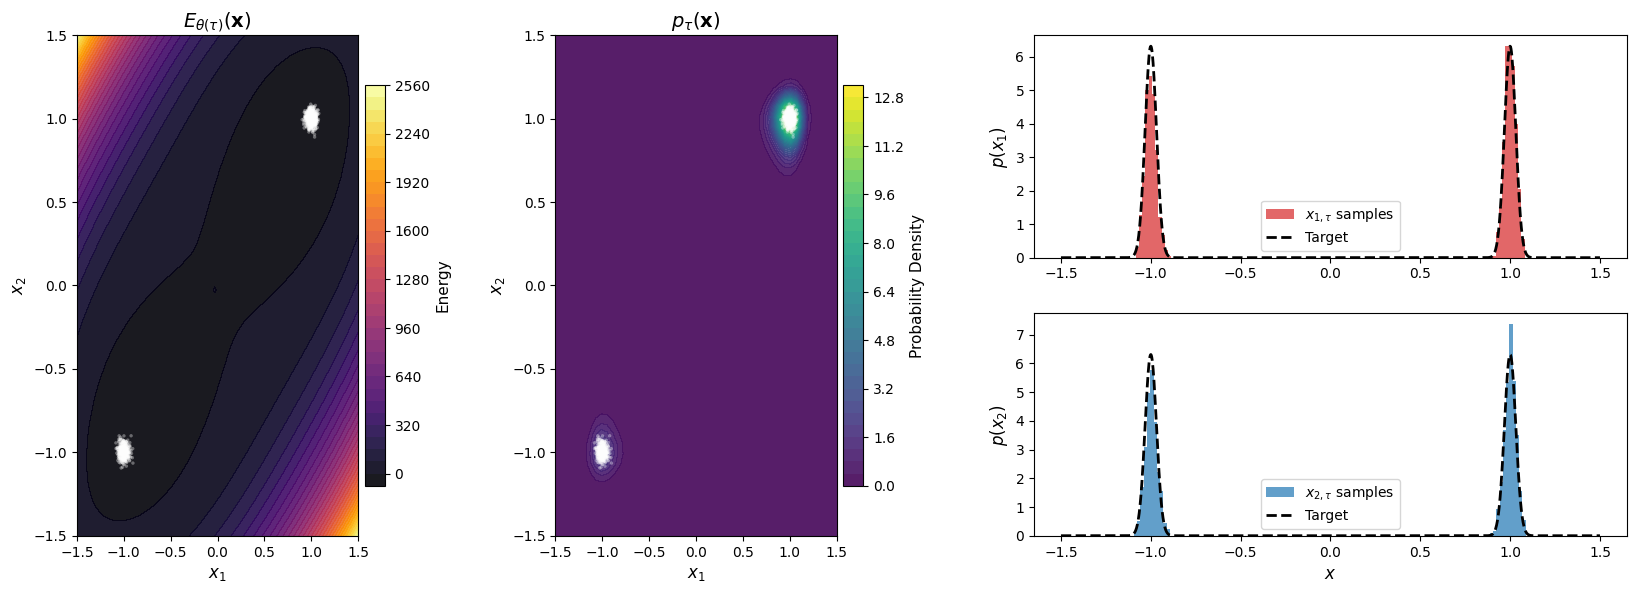

In [56]:
plot_energy_prob_marginals(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle=""  
)

In [77]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import gridspec

def plot_energy_and_marginals(energy_fn, param_list, samples,
                              x1_range=(-2, 2), x2_range=(-2, 2),
                              n_points=100,
                              titles=None,              # row labels (optional)
                              figsize=None,
                              fontsize=12,
                              sample_stride=10,
                              suptitle=r"Energy Landscape and Marginals"):
    """
    Draws, for each parameter set (row):
      • left:  contour of E_{θ(τ)}(x₁,x₂)  (square, equal aspect)
      • mid :  histogram of x₁‑samples     (density)
      • right: histogram of x₂‑samples     (density)
    """
    n_rows = len(param_list)
    if figsize is None:
        figsize = (18, 5.5 * n_rows)
    if titles is None:
        titles = [f"Param Set {i+1}" for i in range(n_rows)]

    fig = plt.figure(figsize=figsize)

    # three equally wide columns: energy | p(x1) | p(x2)
    outer = gridspec.GridSpec(n_rows, 3,
                              width_ratios=[1, 1, 1],
                              wspace=0.35, hspace=0.40)

    # semi‑transparent sample style
    sample_style = dict(c='white', s=6, alpha=0.35, edgecolors='none')

    # pre‑compute grid once
    x1_grid = jnp.linspace(*x1_range, n_points)
    x2_grid = jnp.linspace(*x2_range, n_points)
    X1, X2  = jnp.meshgrid(x1_grid, x2_grid, indexing='ij')

    for row, (params, row_lbl) in enumerate(zip(param_list, titles)):
        # ----- ENERGY -------------------------------------------------------
        ax_E = fig.add_subplot(outer[row, 0], aspect='equal')  # square
        energy = np.zeros((n_points, n_points), dtype=np.float32)
        for i in range(n_points):
            for j in range(n_points):
                energy[i, j] = float(energy_fn(jnp.array([X1[i, j], X2[i, j]]),
                                               params))

        cE = ax_E.contourf(X1, X2, energy, levels=40,
                           cmap='inferno', alpha=0.9)
        fig.colorbar(cE, ax=ax_E, shrink=0.8, pad=0.02
                     ).set_label('Energy', fontsize=fontsize-1)

        ax_E.scatter(samples[::sample_stride, 0],
                     samples[::sample_stride, 1],
                     **sample_style)
        ax_E.set_xlabel('$x_1$', fontsize=fontsize)
        ax_E.set_ylabel('$x_2$', fontsize=fontsize)
        ax_E.tick_params(labelsize=fontsize-2)
        ax_E.set_title(r'$E_{\theta(\tau)}(\mathbf{x})$', fontsize=fontsize+2)

        # ----- MARGINALS ----------------------------------------------------
        bins = 120
        ax_hist_x1 = fig.add_subplot(outer[row, 1])
        ax_hist_x2 = fig.add_subplot(outer[row, 2])

        ax_hist_x1.hist(samples[:, 0], bins=bins, density=True,
                        color='tab:red', alpha=0.7,
                        label=r'$x_{1,\tau}$ samples')
        ax_hist_x2.hist(samples[:, 1], bins=bins, density=True,
                        color='tab:blue', alpha=0.7,
                        label=r'$x_{2,\tau}$ samples')

        # (optional) overlay analytic PDFs if weights/means/covs exist
        if 'weights' in globals():
            grid = np.linspace(x1_range[0], x1_range[1], 1200)
            pdf1 = np.zeros_like(grid)
            pdf2 = np.zeros_like(grid)
            for w, m, c in zip(weights, means, covs):
                pdf1 += w * np.exp(-0.5*((grid - m[0])/np.sqrt(c[0,0]))**2) \
                          / (np.sqrt(c[0,0])*np.sqrt(2*np.pi))
                pdf2 += w * np.exp(-0.5*((grid - m[1])/np.sqrt(c[1,1]))**2) \
                          / (np.sqrt(c[1,1])*np.sqrt(2*np.pi))
            ax_hist_x1.plot(grid, pdf1, '--k', lw=2, label='Target')
            ax_hist_x2.plot(grid, pdf2, '--k', lw=2, label='Target')

        for ax, lbl in zip((ax_hist_x1, ax_hist_x2),
                           (r'$p(x_1)$', r'$p(x_2)$')):
            ax.set_ylabel(lbl, fontsize=fontsize)
            ax.tick_params(labelsize=fontsize-2)
            ax.legend(fontsize=fontsize-3)

        ax_hist_x2.set_xlabel('$x$', fontsize=fontsize)

        # row label (optional)
        ax_E.annotate(row_lbl, xy=(0, 1.02), xycoords='axes fraction',
                      fontsize=fontsize+1, ha='left', va='bottom')

    if suptitle:
        fig.suptitle(suptitle, fontsize=fontsize+4, y=0.97)

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_176678/3280325160.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


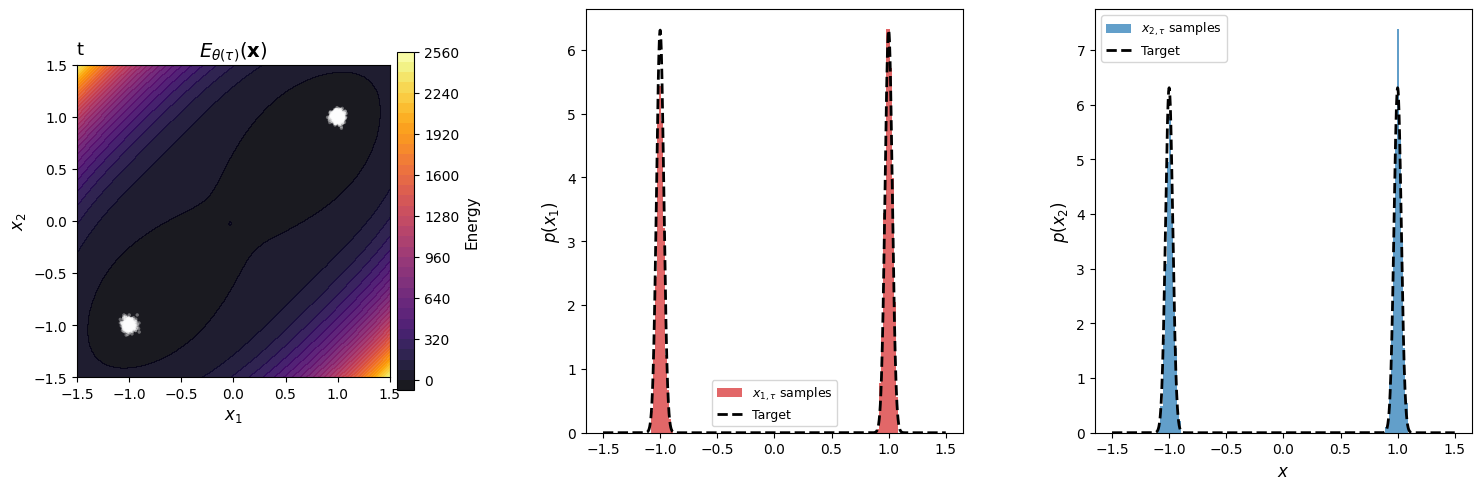

In [79]:

plot_energy_and_marginals(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),
    x2_range=(-1.5, 1.5),
    n_points=50,
    titles="test",
    fontsize=12,
    suptitle=""
)
